# Pedestrian + Crosswalk Detector (YOLOv8) — trainv3
Object detector for **pedestrians** and **crosswalks**, trained on a filtered-down subset of the Roboflow
[`N_O_2`](https://universe.roboflow.com/nada-majd-e4uhb/n_o_2) dataset.

`N_O_2` actually has 70 classes (car, truck, bus, dozens of sign types, traffic lights, etc.) we only
want 2 of them (`person`, `cross walk`), so this notebook downloads the full thing once, then filters and
remaps the label files down to just those 2 classes before training. 

## 1. Setup & imports

In [1]:
!pip install ultralytics roboflow --quiet

import os
import shutil
import yaml
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from ultralytics import YOLO
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 114.1 MB/s eta 0:00:0000:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
CUDA available: True
GPU: Tesla T4


## 2. Config

In [2]:
ROBOFLOW_API_KEY = "M7b9N8fKVdRTuOBDC6TH" 

PED_ROBOFLOW_WORKSPACE = "nada-majd-e4uhb"
PED_ROBOFLOW_PROJECT = "n_o_2"
PED_ROBOFLOW_VERSION = 23  

PED_DATASET_FORMAT = "yolov8"
PED_RAW_DATA_DIR = "/kaggle/working/n_o_2_raw"
PED_FILTERED_DATA_DIR = "/kaggle/working/n_o_2_filtered"

TARGET_CLASS_NAMES = ["person", "cross walk"]

PED_RUNS_DIR = "/kaggle/working/runs"
PED_RUN_NAME = "ped_crosswalk_yolo"

PED_MODEL_SIZE = "yolov8n.pt"
PED_IMG_SIZE = 640
PED_EPOCHS = 60
PED_BATCH = 16
PED_PATIENCE = 10


## 3. Download the full dataset from Roboflow
This pulls all 70 classes — we cut it down to 2 in the next section, this step just gets everything
onto disk first.

In [3]:
from roboflow import Roboflow

rf_ped = Roboflow(api_key=ROBOFLOW_API_KEY)
ped_project = rf_ped.workspace(PED_ROBOFLOW_WORKSPACE).project(PED_ROBOFLOW_PROJECT)

ped_version = ped_project.version(PED_ROBOFLOW_VERSION)
ped_dataset_raw = ped_version.download(PED_DATASET_FORMAT, location=PED_RAW_DATA_DIR)

print("Full dataset downloaded to:", ped_dataset_raw.location)


loading Roboflow workspace...
loading Roboflow project...
Full dataset downloaded to: /kaggle/working/n_o_2_raw


## 3a. Discover the real class names
Confirm `TARGET_CLASS_NAMES` above actually match strings in this dataset's `data.yaml` — fix the spelling
here if not (e.g. it might be `crosswalk` with no space, or a different order) before filtering anything.

In [4]:
import random
raw_data_yaml_path = os.path.join(ped_dataset_raw.location, "data.yaml")

with open(raw_data_yaml_path, "r") as f:
    raw_data_config = yaml.safe_load(f)

orig_names = raw_data_config["names"]
print(f"{len(orig_names)} classes in the raw dataset:")
print(orig_names)

# Build name -> original id lookup, whichever format Roboflow exported (list or dict)
if isinstance(orig_names, dict):
    orig_name_to_id = {v: int(k) for k, v in orig_names.items()}
else:
    orig_name_to_id = {name: i for i, name in enumerate(orig_names)}

missing = [name for name in TARGET_CLASS_NAMES if name not in orig_name_to_id]
if missing:
    print(f"\n *** WARNING: these target names weren't found verbatim: {missing} ***")
    print(" *** Check the class list above and fix TARGET_CLASS_NAMES in the config cell. ***")
else:
    print(f"\nAll target classes found. Original IDs: {[orig_name_to_id[n] for n in TARGET_CLASS_NAMES]}")


5 classes in the raw dataset:
['cross walk', 'green', 'person', 'red', 'yellow']

All target classes found. Original IDs: [2, 0]


## 4. Filter + remap labels down to just the target classes
Keeps every image (background images with no boxes are fine for YOLO — they help reduce false positives),
but rewrites each label file so it only contains `person` / `cross walk` boxes, remapped to new ids
0 and 1 so they line up with a fresh 2-class `data.yaml`.

In [5]:
# original_id -> new_id (0, 1, ...) only for the classes we're keeping
old_id_to_new_id = {orig_name_to_id[name]: new_id for new_id, name in enumerate(TARGET_CLASS_NAMES)}

def filter_split(split):
    src_img_dir = os.path.join(ped_dataset_raw.location, split, "images")
    src_label_dir = os.path.join(ped_dataset_raw.location, split, "labels")
    dst_img_dir = os.path.join(PED_FILTERED_DATA_DIR, split, "images")
    dst_label_dir = os.path.join(PED_FILTERED_DATA_DIR, split, "labels")

    if not os.path.exists(src_img_dir):
        print(f"  {split}: source not found, skipping")
        return 0, 0

    os.makedirs(dst_img_dir, exist_ok=True)
    os.makedirs(dst_label_dir, exist_ok=True)

    img_files = [f for f in os.listdir(src_img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    kept_boxes = 0

    for img_file in img_files:
        label_file = os.path.splitext(img_file)[0] + ".txt"
        src_label_path = os.path.join(src_label_dir, label_file)

        filtered_lines = []
        if os.path.exists(src_label_path):
            with open(src_label_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if not parts:
                        continue
                    old_cls_id = int(parts[0])
                    if old_cls_id in old_id_to_new_id:
                        parts[0] = str(old_id_to_new_id[old_cls_id])
                        filtered_lines.append(" ".join(parts))

        # Copy image regardless (even if it ends up with zero boxes after filtering)
        shutil.copy(os.path.join(src_img_dir, img_file), os.path.join(dst_img_dir, img_file))
        with open(os.path.join(dst_label_dir, label_file), "w") as f:
            f.write("\n".join(filtered_lines))

        kept_boxes += len(filtered_lines)

    print(f"  {split}: {len(img_files)} images copied, {kept_boxes} target-class boxes kept")
    return len(img_files), kept_boxes

print("Filtering each split down to person + cross walk:")


# Only "train" actually exists in the raw download — filter just that
print("Filtering the only available split (train):")
filter_split("train")

# Roboflow didn't ship a valid/test split for this version, so carve our own
# validation set out of the filtered train data.
random.seed(42)

full_img_dir = os.path.join(PED_FILTERED_DATA_DIR, "train", "images")
full_label_dir = os.path.join(PED_FILTERED_DATA_DIR, "train", "labels")
val_img_dir = os.path.join(PED_FILTERED_DATA_DIR, "valid", "images")
val_label_dir = os.path.join(PED_FILTERED_DATA_DIR, "valid", "labels")
os.makedirs(val_img_dir, exist_ok=True)
os.makedirs(val_label_dir, exist_ok=True)

all_imgs = [f for f in os.listdir(full_img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
random.shuffle(all_imgs)

VAL_FRACTION = 0.15
n_val = int(len(all_imgs) * VAL_FRACTION)
val_imgs = all_imgs[:n_val]

for img_file in val_imgs:
    label_file = os.path.splitext(img_file)[0] + ".txt"
    shutil.move(os.path.join(full_img_dir, img_file), os.path.join(val_img_dir, img_file))
    src_label = os.path.join(full_label_dir, label_file)
    if os.path.exists(src_label):
        shutil.move(src_label, os.path.join(val_label_dir, label_file))

print(f"Moved {len(val_imgs)} images into a new validation split "
      f"({len(all_imgs) - len(val_imgs)} remain in train)")

ped_data_yaml_path = os.path.join(PED_FILTERED_DATA_DIR, "data.yaml")
filtered_config = {
    "train": os.path.join(PED_FILTERED_DATA_DIR, "train", "images"),
    "val": os.path.join(PED_FILTERED_DATA_DIR, "valid", "images"),
    "nc": len(TARGET_CLASS_NAMES),
    "names": TARGET_CLASS_NAMES,
}
with open(ped_data_yaml_path, "w") as f:
    yaml.dump(filtered_config, f)

print(f"\nFiltered data.yaml written to {ped_data_yaml_path}")
print(filtered_config)

Filtering each split down to person + cross walk:
Filtering the only available split (train):
  train: 1872 images copied, 4371 target-class boxes kept
Moved 280 images into a new validation split (1592 remain in train)

Filtered data.yaml written to /kaggle/working/n_o_2_filtered/data.yaml
{'train': '/kaggle/working/n_o_2_filtered/train/images', 'val': '/kaggle/working/n_o_2_filtered/valid/images', 'nc': 2, 'names': ['person', 'cross walk']}


## 5. Sanity-check the filtered labels before trusting anything
Draws the remapped boxes on a handful of training images — confirm `person`/`cross walk` line up
correctly, not e.g. every box showing as class 0.

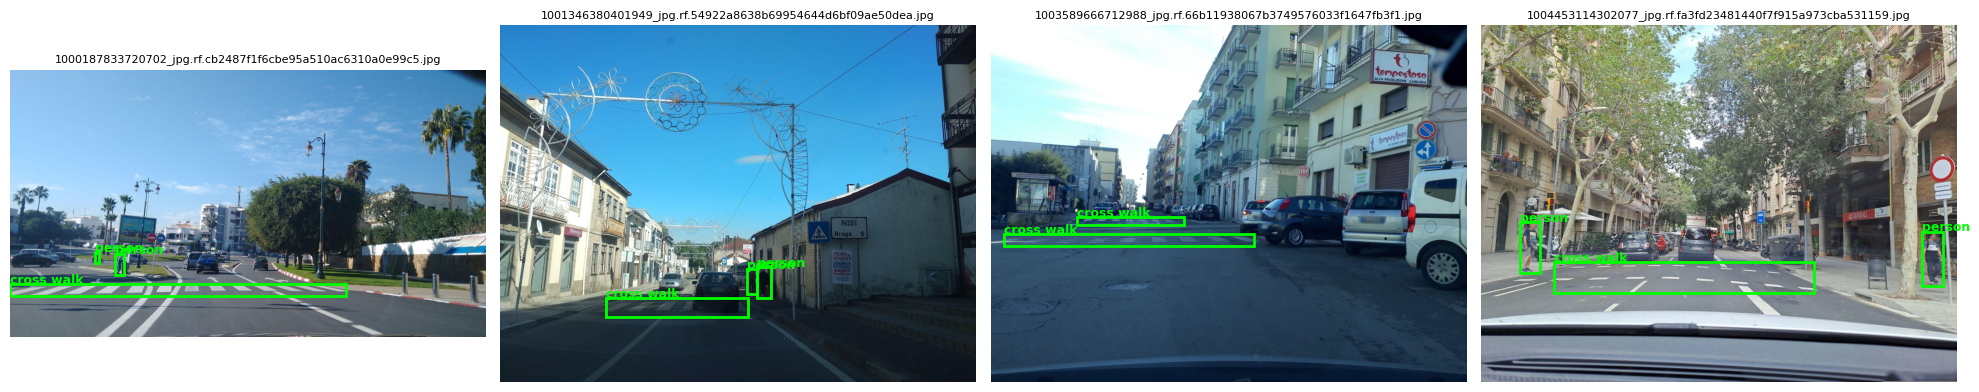

In [6]:
def preview_ped_labels(split="train", count=4):
    img_dir = os.path.join(PED_FILTERED_DATA_DIR, split, "images")
    label_dir = os.path.join(PED_FILTERED_DATA_DIR, split, "labels")

    # prefer images that actually have a box, so the check is meaningful
    candidates = []
    for f in os.listdir(img_dir):
        if not f.lower().endswith((".jpg", ".jpeg", ".png")):
            continue
        label_path = os.path.join(label_dir, os.path.splitext(f)[0] + ".txt")
        if os.path.exists(label_path) and os.path.getsize(label_path) > 0:
            candidates.append(f)

    img_files = sorted(candidates)[:count]
    if not img_files:
        print("No labeled images found to preview — check the filtering step above.")
        return

    fig, axes = plt.subplots(1, len(img_files), figsize=(5 * len(img_files), 5))
    if len(img_files) == 1:
        axes = [axes]

    for ax, img_file in zip(axes, img_files):
        img_path = os.path.join(img_dir, img_file)
        label_path = os.path.join(label_dir, os.path.splitext(img_file)[0] + ".txt")

        img = Image.open(img_path)
        w, h = img.size
        ax.imshow(img)

        with open(label_path, "r") as f:
            for line in f:
                cls_id, xc, yc, bw, bh = map(float, line.strip().split())
                x1 = (xc - bw / 2) * w
                y1 = (yc - bh / 2) * h
                box_w = bw * w
                box_h = bh * h
                rect = patches.Rectangle((x1, y1), box_w, box_h, linewidth=2, edgecolor="lime", facecolor="none")
                ax.add_patch(rect)
                ax.text(x1, y1 - 5, TARGET_CLASS_NAMES[int(cls_id)], color="lime", fontsize=9, weight="bold")

        ax.set_title(img_file, fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

preview_ped_labels("train", count=4)


## 6. Train the detector (transfer learning on YOLOv8n, COCO-pretrained)

In [7]:
ped_model = YOLO(PED_MODEL_SIZE)

ped_results = ped_model.train(
    data=ped_data_yaml_path,
    epochs=PED_EPOCHS,
    imgsz=PED_IMG_SIZE,
    batch=PED_BATCH,
    patience=PED_PATIENCE,
    project=PED_RUNS_DIR,
    name=PED_RUN_NAME,
    seed=42,
)


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/n_o_2_filtered/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ped_crosswalk_yolo-4, nbs=64, nms=False, opset=None, optimize=False, optim

## 7. Plot training curves

In [8]:
ped_results_png = os.path.join(PED_RUNS_DIR, PED_RUN_NAME, "results.png")

if os.path.exists(ped_results_png):
    img = Image.open(ped_results_png)
    plt.figure(figsize=(14, 8))
    plt.imshow(img)
    plt.axis("off")
    plt.show()
else:
    print(f"results.png not found at {ped_results_png} — check PED_RUNS_DIR/PED_RUN_NAME match training output above.")


results.png not found at /kaggle/working/runs/ped_crosswalk_yolo/results.png — check PED_RUNS_DIR/PED_RUN_NAME match training output above.


## 8. Validate on the held-out validation split

In [9]:
ped_metrics = ped_model.val()

print("mAP50:", ped_metrics.box.map50)
print("mAP50-95:", ped_metrics.box.map)
print("\nPer-class mAP50:")
for i, cls_name in enumerate(TARGET_CLASS_NAMES):
    try:
        print(f"  {cls_name}: {ped_metrics.box.ap50[i]:.3f}")
    except (IndexError, KeyError):
        pass


Ultralytics 8.4.98 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4212.9±982.2 MB/s, size: 354.2 KB)
val: Scanning /kaggle/working/n_o_2_filtered/valid/labels.cache... 704 images, 123 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 704/704 268.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 44/44 6.3it/s 7.0s0.2s
                   all        704       1554      0.805      0.712      0.795      0.509
                person        358       1067      0.799      0.733      0.813      0.545
            cross walk        425        487      0.812      0.691      0.777      0.472
Speed: 0.9ms preprocess, 3.1ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val-3
mAP50: 0.7948597747682246
mAP50-95: 0.5085970439584201

Per-class mAP50:

## 9. Quick visual test — run inference on a few validation images

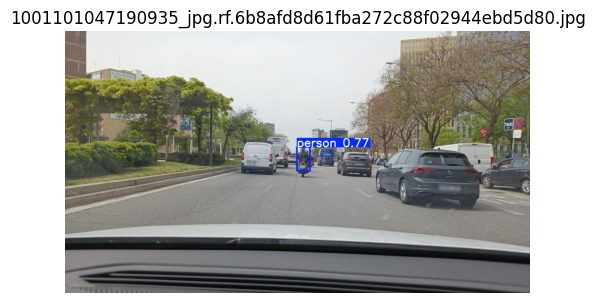

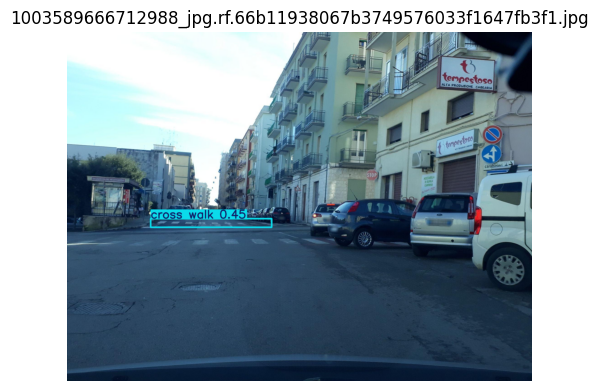

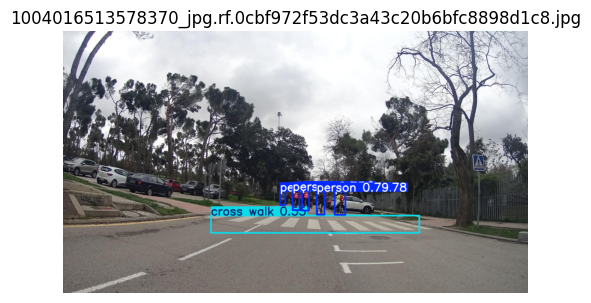

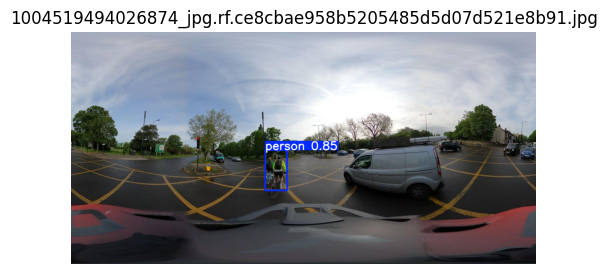

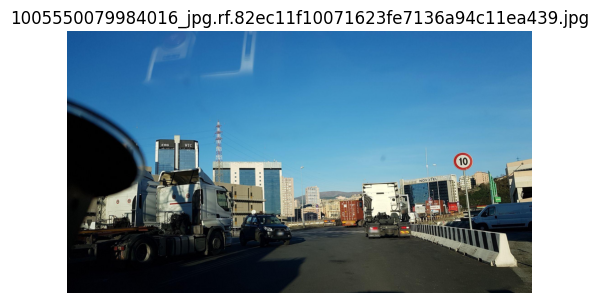

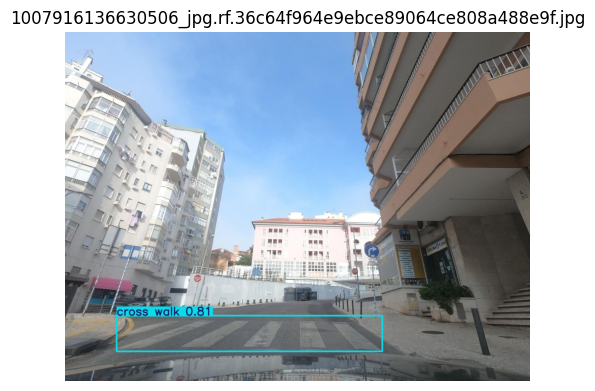

In [10]:
ped_best_weights = os.path.join(PED_RUNS_DIR, "ped_crosswalk_yolo-2", "weights", "best.pt")
ped_trained_model = YOLO(ped_best_weights)

ped_val_img_dir = os.path.join(PED_FILTERED_DATA_DIR, "valid", "images")
ped_sample_files = sorted([f for f in os.listdir(ped_val_img_dir) if f.lower().endswith((".jpg", ".jpeg", ".png"))])[:6]
for f in ped_sample_files:
    img_path = os.path.join(ped_val_img_dir, f)
    result = ped_trained_model.predict(img_path, conf=0.4, verbose=False)[0]
    annotated = result.plot()
    annotated_rgb = annotated[..., ::-1]
    plt.figure(figsize=(6, 6))
    plt.imshow(annotated_rgb)
    plt.title(f)
    plt.axis("off")
    plt.show()

## 10. Export weights
Same loading pattern as your other YOLO models: `YOLO(weights_path)` then `.predict(image_path)`.

In [11]:
ped_export_path = "/kaggle/working/ped_crosswalk_detector.pt"
shutil.copy(ped_best_weights, ped_export_path)

print(f"Saved to {ped_export_path} — download from the notebook's Output tab.")
print(f"Classes: {TARGET_CLASS_NAMES}")


Saved to /kaggle/working/ped_crosswalk_detector.pt — download from the notebook's Output tab.
Classes: ['person', 'cross walk']


## Next steps
Once you've confirmed this one works too, both `speed_bump_detector.pt` and `ped_crosswalk_detector.pt`
are ready to wire into `fullwithsigns` — see the accompanying message for exactly which cells to
add/change there for the speed bump model; the pedestrian + crosswalk wiring follows the identical
pattern once you're happy with this notebook's results.
